# 01 — Segmentação
Compara dois métodos de segmentação: **Threshold HSV** e **Otsu (escala de cinza)**.
A máscara gerada aqui será usada nos notebooks seguintes para extrair features apenas da fruta, ignorando o fundo.

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

## Configuração de caminhos

In [8]:
DATA_DIR = Path('../data')
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# Busca apenas nas pastas fresh/ e rotten/ (ignora dataset/)
imagens = []
for classe in ['fresh', 'rotten']:
    imagens += list((DATA_DIR / classe).glob('*.png'))
    imagens += list((DATA_DIR / classe).glob('*.jpg'))
    imagens += list((DATA_DIR / classe).glob('*.jpeg'))

print(f'{len(imagens)} imagens encontradas')
print('Exemplo:', imagens[0] if imagens else 'Nenhuma — rode organizar_dataset.py primeiro')

200 imagens encontradas
Exemplo: ../data/fresh/fresh_0022.png


## Funções de segmentação

In [9]:
def segmentar_otsu(img_bgr):
    """
    Método 2: Threshold de Otsu em escala de cinza.
    Encontra automaticamente o limiar que melhor separa fundo e objeto.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask


def segmentar_hsv(img_bgr):
    """
    Método 1: Threshold no espaço HSV com fallback para Otsu.
    Remove fundo branco/claro pela saturação mínima.
    Se a máscara ficar vazia (fundo cinza/escuro), usa Otsu automaticamente.
    """
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 30, 50])
    upper = np.array([180, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    # Fallback: se menos de 5% da imagem foi segmentada, usa Otsu
    taxa = mask.sum() / 255 / (256 * 256)
    if taxa < 0.05:
        mask = segmentar_otsu(img_bgr)
    return mask


def aplicar_mascara(img_bgr, mask):
    resultado = img_bgr.copy()
    resultado[mask == 0] = 0
    return resultado

## Visualização: comparação entre os dois métodos
Testa em 4 imagens (2 fresh, 2 rotten).

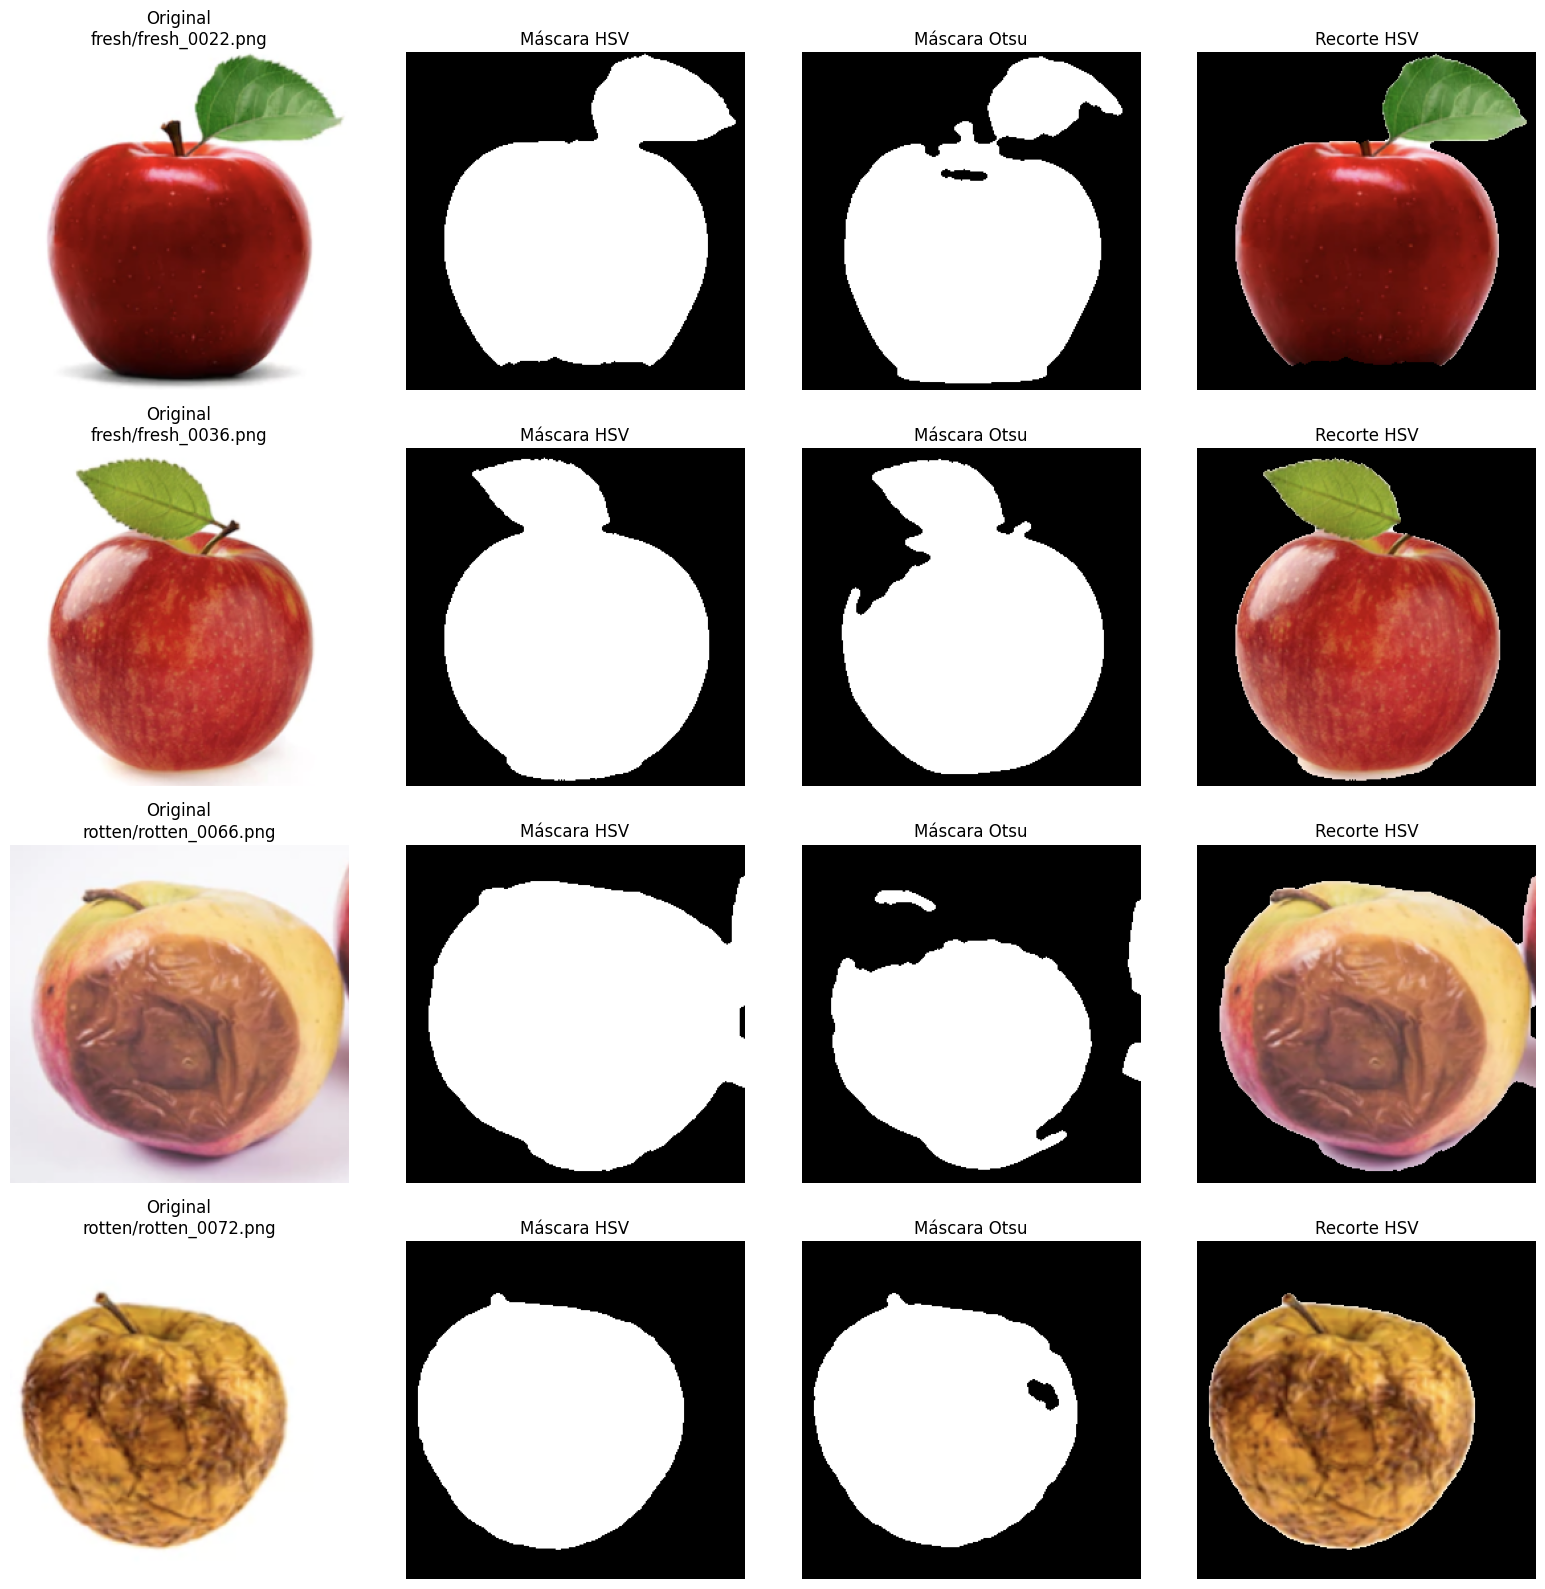

Figura salva em outputs/segmentacao_comparacao.png


In [10]:
# Pega 2 fresh e 2 rotten para visualização
fresh_imgs  = [p for p in imagens if p.parent.name == 'fresh'][:2]
rotten_imgs = [p for p in imagens if p.parent.name == 'rotten'][:2]
amostras = fresh_imgs + rotten_imgs

fig, axes = plt.subplots(len(amostras), 4, figsize=(16, 4 * len(amostras)))
colunas = ['Original', 'Máscara HSV', 'Máscara Otsu', 'Recorte HSV']

for i, path in enumerate(amostras):
    img = cv2.imread(str(path))
    img = cv2.resize(img, (256, 256))

    mask_hsv  = segmentar_hsv(img)
    mask_otsu = segmentar_otsu(img)
    recorte   = aplicar_mascara(img, mask_hsv)

    ax_row = axes[i] if len(amostras) > 1 else axes
    ax_row[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax_row[0].set_title(f'{colunas[0]}\n{path.parent.name}/{path.name}')
    ax_row[1].imshow(mask_hsv,  cmap='gray')
    ax_row[1].set_title(colunas[1])
    ax_row[2].imshow(mask_otsu, cmap='gray')
    ax_row[2].set_title(colunas[2])
    ax_row[3].imshow(cv2.cvtColor(recorte, cv2.COLOR_BGR2RGB))
    ax_row[3].set_title(colunas[3])

    for ax in ax_row:
        ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'segmentacao_comparacao.png', dpi=150)
plt.show()
print('Figura salva em outputs/segmentacao_comparacao.png')

## Método escolhido para o pipeline

In [11]:
# HSV com fallback Otsu já cobre os dois casos (fundo branco e fundo escuro)
SEGMENTAR = segmentar_hsv
print(f'Método selecionado: {SEGMENTAR.__name__}')

Método selecionado: segmentar_hsv


## Teste em batch: taxa de pixels segmentados

In [12]:
taxas = []
for path in imagens:
    img = cv2.imread(str(path))
    img = cv2.resize(img, (256, 256))
    mask = SEGMENTAR(img)
    taxa = mask.sum() / 255 / (256 * 256)
    taxas.append({'arquivo': path.name, 'classe': path.parent.name, 'taxa_segmentada': round(taxa, 3)})

df_taxas = pd.DataFrame(taxas)
print(df_taxas.groupby('classe')['taxa_segmentada'].describe().round(3))

problematicas = df_taxas[(df_taxas['taxa_segmentada'] < 0.05) | (df_taxas['taxa_segmentada'] > 0.95)]
if len(problematicas):
    print(f'\n⚠️  {len(problematicas)} imagens com segmentação suspeita:')
    print(problematicas.to_string(index=False))
else:
    print('\n✓ Nenhuma imagem com segmentação suspeita.')

        count   mean    std    min    25%    50%    75%    max
classe                                                        
fresh   100.0  0.537  0.064  0.389  0.499  0.538  0.585  0.677
rotten  100.0  0.572  0.120  0.287  0.493  0.570  0.632  1.000

⚠️  3 imagens com segmentação suspeita:
        arquivo classe  taxa_segmentada
rotten_0061.png rotten            0.987
rotten_0082.png rotten            0.970
rotten_0083.png rotten            1.000
